In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
Diabetes_Disease_df=pd.read_csv("../data/diabetes_disease.csv")

In [12]:
print(Diabetes_Disease_df.index)
print(Diabetes_Disease_df.head(10))

RangeIndex(start=0, stop=768, step=1)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      197             70             45      543  30.5   
9            8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32     

In [13]:
print(Diabetes_Disease_df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [14]:
print(Diabetes_Disease_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [15]:
print(Diabetes_Disease_df.isna().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [16]:
print(Diabetes_Disease_df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [17]:
Diabetes_Disease_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


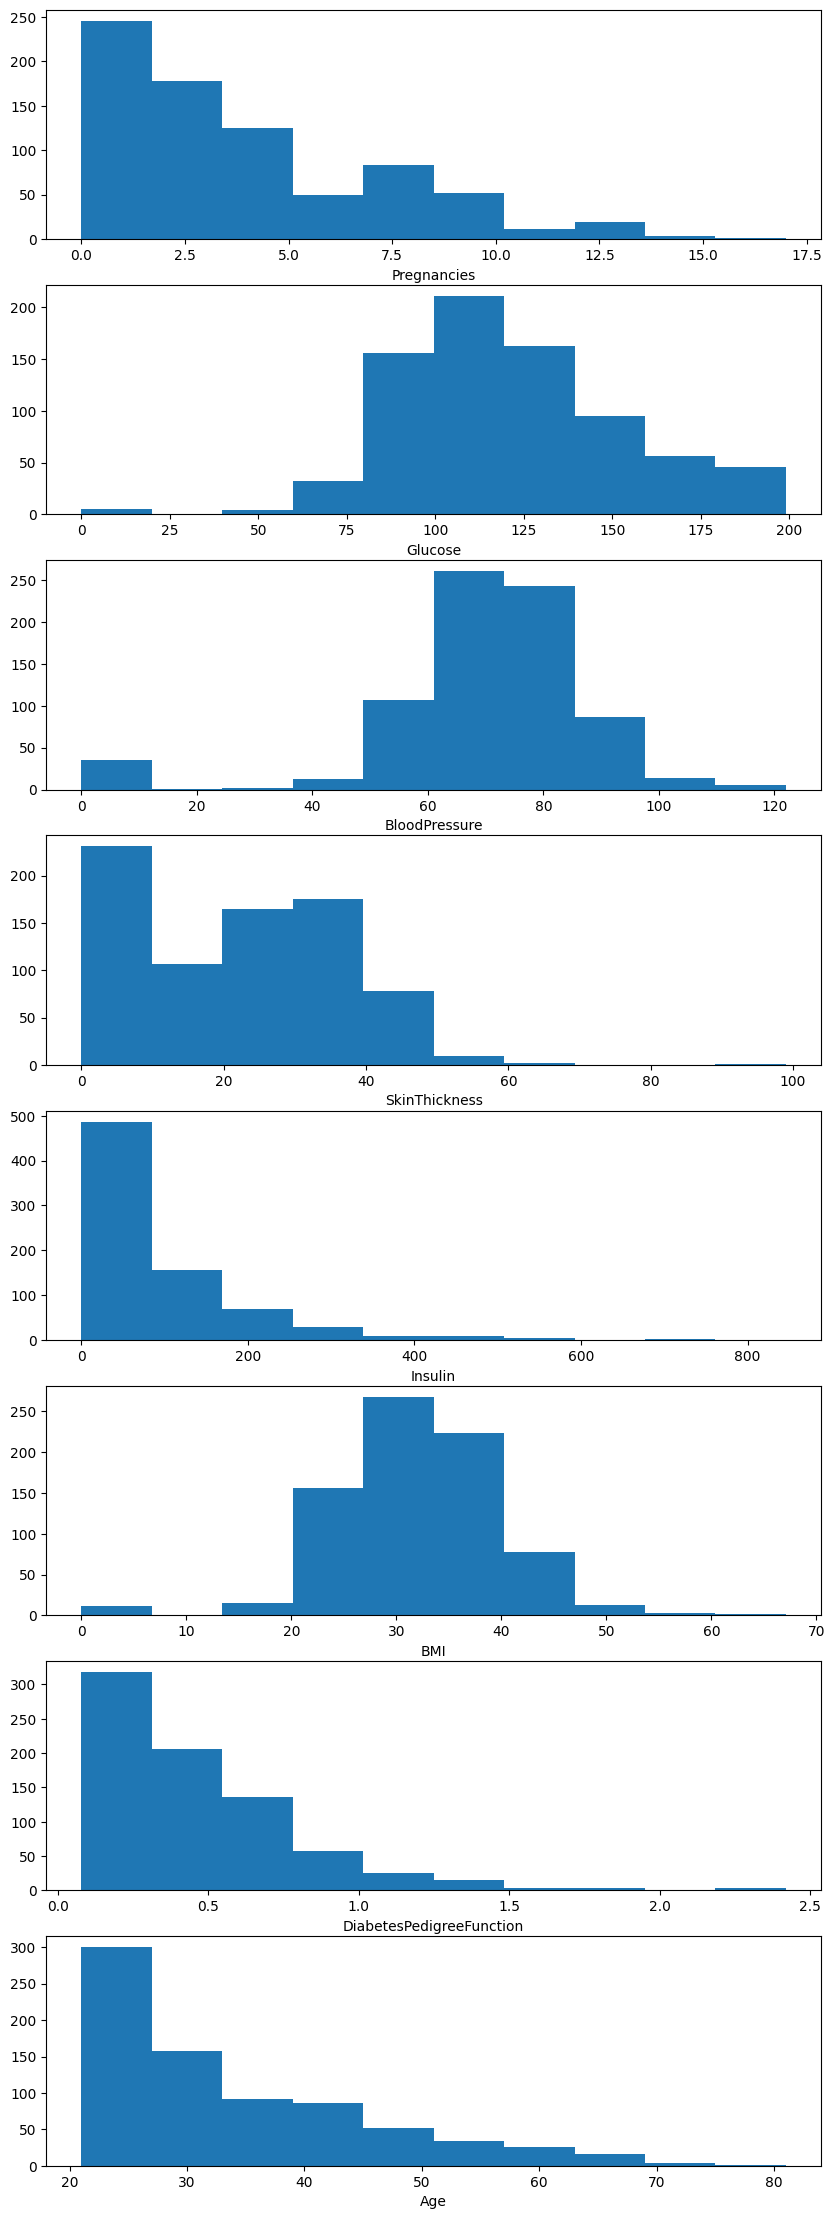

In [18]:
features=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
fig , ax = plt.subplots(8,1)
for fetur in range(0,8):
    ax[fetur].hist(Diabetes_Disease_df[features[fetur]])
    ax[fetur].set_xlabel(features[fetur])
fig.set_size_inches([10,28])
plt.show()

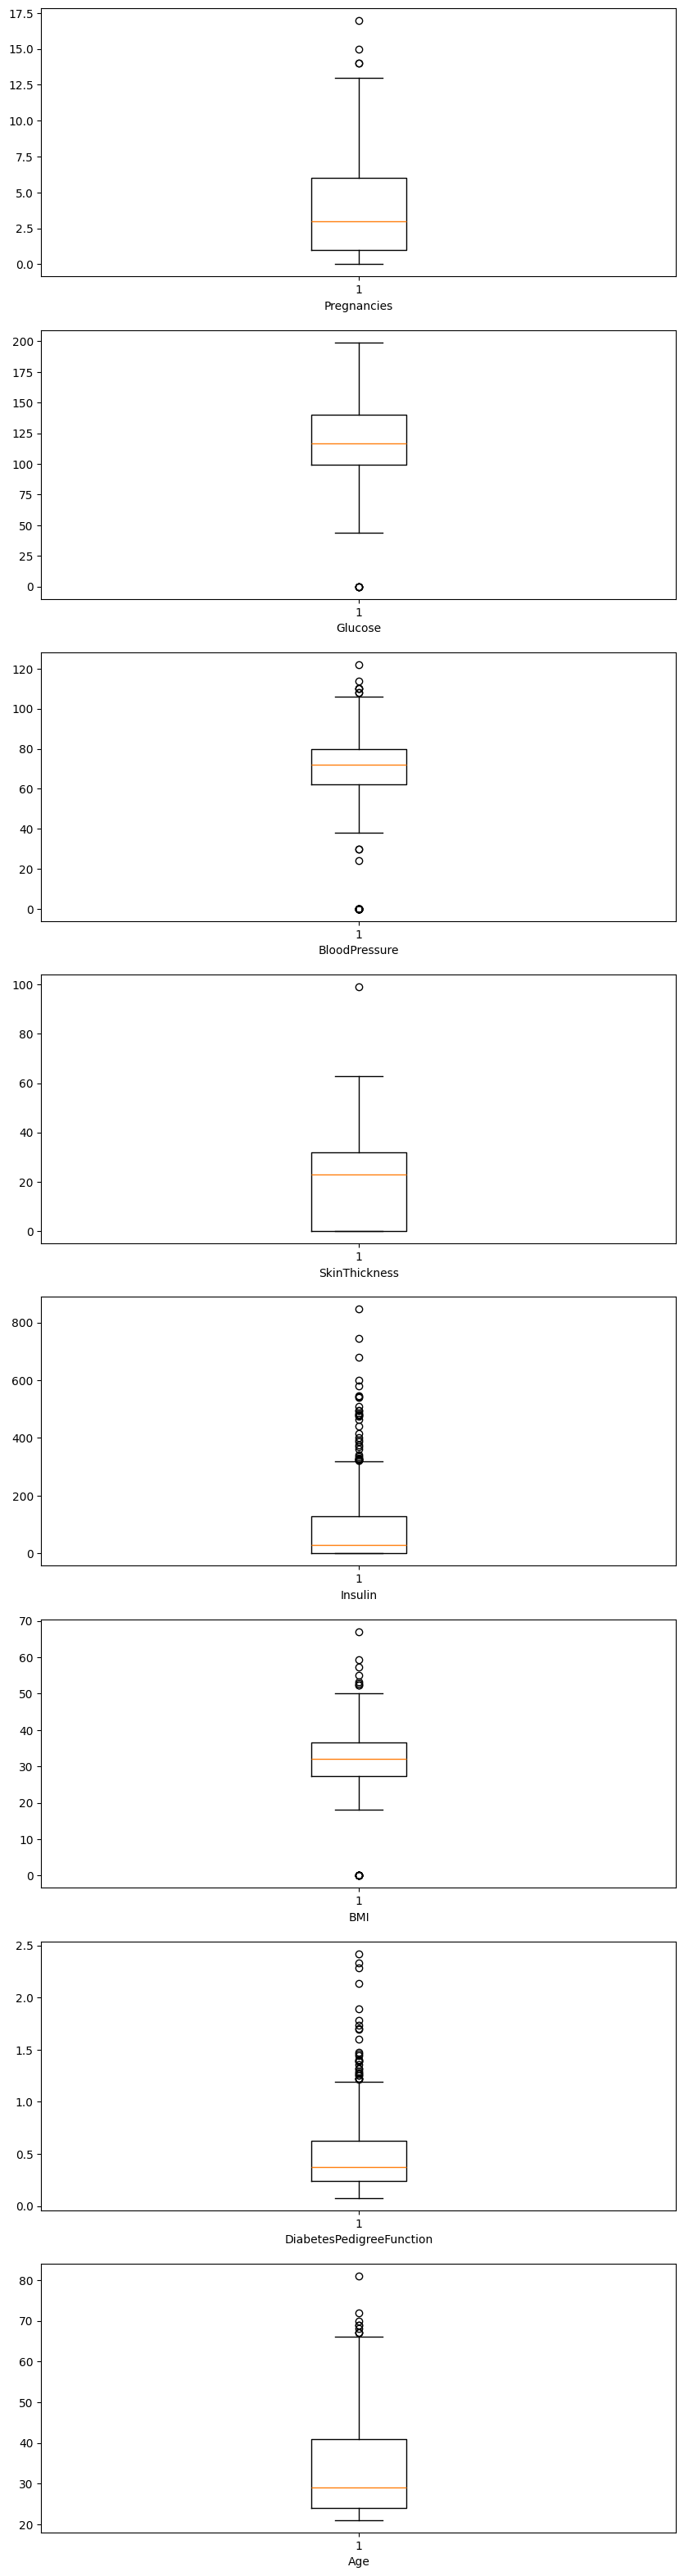

In [19]:
fig , ax = plt.subplots(8,1)
for fetur in range(0,8):
    ax[fetur].boxplot(Diabetes_Disease_df[features[fetur]])
    ax[fetur].set_xlabel(features[fetur])
fig.set_size_inches([10,40])
plt.show()

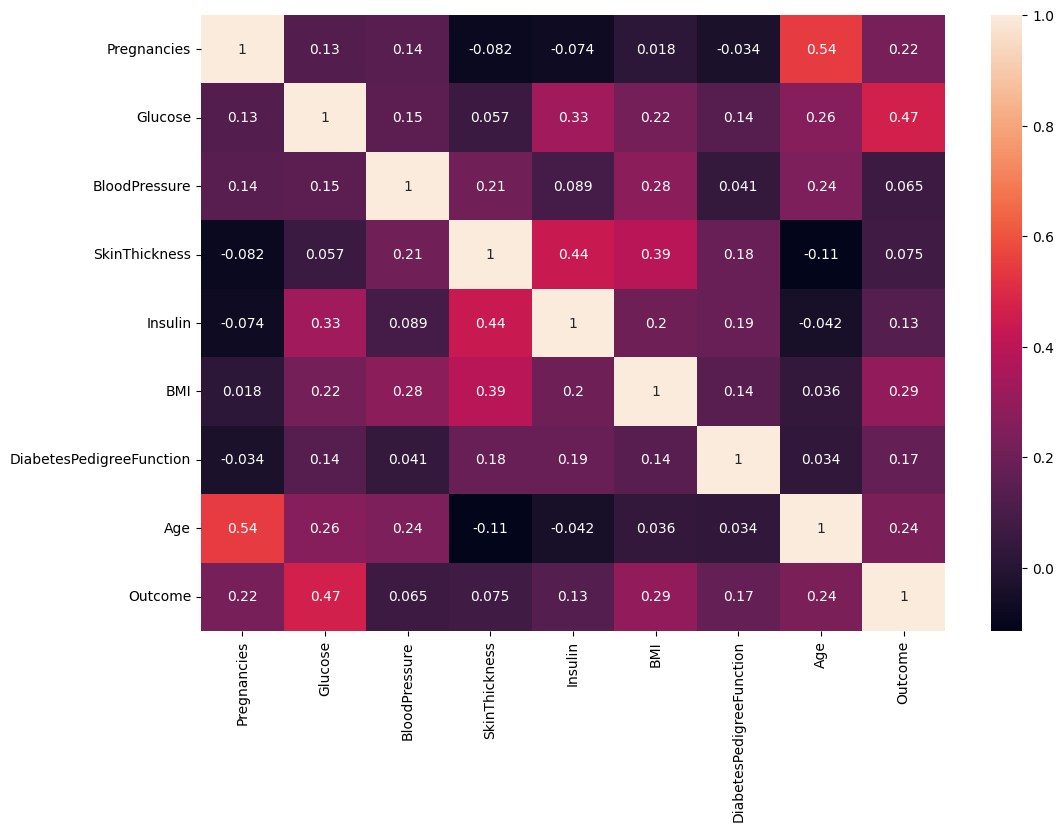

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(Diabetes_Disease_df.corr(),annot=True)
plt.show()

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [22]:
X=Diabetes_Disease_df.drop("Outcome",axis=1).values
y=Diabetes_Disease_df["Outcome"].values
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [24]:
steps=[("scaling",StandardScaler()),
        ("logistic_regression",LogisticRegression())]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/diabetes/diabetes_logistic_regression_report.csv")

In [28]:
steps=[("scaling",StandardScaler()),
        ("svm",SVC())]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/diabetes/diabetes_SVM_report.csv")

In [ ]:
import os
__file__="DiseasePrediction"
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
data=model_file = os.path.join(BASE_DIR, "models", "diabetes_pipline.pkl")

In [31]:
import joblib
joblib.dump(pipeline,'../models/diabetes_pipline.pkl')

['../models/diabetes_pipline.pkl']

In [29]:
steps=[("scaling",StandardScaler()),
        ("random_forest",RandomForestClassifier())]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/diabetes/diabetes_RandomForest_report.csv")

In [30]:
steps=[("scaling",StandardScaler()),
        ("xgboost",XGBClassifier())]
pipeline=Pipeline(steps)
pipeline.fit(X_train,y_train)
y_pred=pipeline.predict(X_test)
report=classification_report(y_test,y_pred,output_dict=True)
report_df=pd.DataFrame(report).transpose()
report_df.to_csv("../results/diabetes/diabetes_xgboost_report.csv")